# Alanyze data using behavioral model
There are 3 models with different parameter combinations:

1. <b>The Bayesian model (Schwöbel et al. 2021):</b> \
   <b>a.</b> With 3 parameters: a policy forgetting rate $\lambda_{\pi}$, a reward forgetting rate $\lambda_{r}$, and a decision temparature $\beta$. \
   <b>b.</b> With 4 parameters: a policy forgetting rate $\lambda_{\pi}$, a reward forgetting rate $\lambda_{r}$, a decision temparature $\beta$, and a habitual tendency $h$.
2. <b>A newer MF/MB version that is better for fitting (Otto et al. 2013):</b> \
<b>Note:</b> This is not quite the original version, as the Q-values in the original work did not converge to the true expected values. Instead, I implemented a "bug-fixed" version.\
   <b>a.</b> With 4 parameters: a MF weight parameter $\beta_{MF}$, a MB weight parameter $\beta_{MB}$, a learning rate $\alpha$, and a dicount factor $\lambda$. \
   <b>b.</b> With 5 parameters: a MF weight parameter $\beta_{MF}$, a MB weight parameter $\beta_{MB}$, a learning rate $\alpha$, and a dicount factor $\lambda$$, and a repetition/perserveration parameter $p$. \
3. <b>The original model-free/model-based (MF/MB) model (Daw et al. 2005, 2011):</b> \
   <b>a.</b> With 4 parameters: a weighting parameters $\omega$, a decision temperature $\beta$, a learning rate $\alpha$, and a dicount factor $\lambda$. \
   <b>b.</b> With 5 parameters: a weighting parameter $\omega$, a decision temperature $\beta$, a learning rate $\alpha$, a dicount factor $\lambda$, and a repetition/perserveration parameter $p$.

Tell python that the code in the submodule is code that we want to import and run

In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','..','code','BalancingControl'))

import two_stage_utils as tu
import inference as inf
import inference_utils as iu

torch threads 1


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on device cpu
torch threads 1


Other imports that we need for simulation, inference, and plotting

In [2]:
import torch
import pyro

import os
from scipy.io import loadmat
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
import pickle as pkl
import json
import gc

Define where results should be saved

In [3]:
results_folder = "results"
inference_folder = os.path.join(results_folder, "inference")

In [4]:
processed_data_folder = "processed_data"

full_data_fname = "full_data.csv"
full_data_file = os.path.join(processed_data_folder, full_data_fname)

full_data_df = pd.read_csv(full_data_file)

statistics_folder = os.path.join(results_folder, "statistics")

scores_file_name = "scores.csv"
scores_file = os.path.join(statistics_folder, scores_file_name)

structured_data_fname = "structured_data.pkl"
structured_data_file = os.path.join(processed_data_folder, structured_data_fname)

In [5]:
# number of simulated agents/participants
n_agents = int(full_data_df['subject'].max()+1)
print(n_agents)

206


In [6]:
with open(structured_data_file, "rb") as f:
    data = pkl.load(f)

for key in data.keys():
    data[key] = torch.from_numpy(data[key])

# print(data)

#### Global experiment parameters

In [7]:
trials =  150#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
p_invalid = 1.-1./201.

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_invalid}

Define states and transition matrices

In [8]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

### load behavioral outputs of participants: mf-/mb-scores

In [9]:
scores_df = pd.read_csv(scores_file).drop(columns='Unnamed: 0')

Now we can start :) 

### 1. BCC:
### 1.a 3 parameter version

Simulation pre-setup

In [10]:
# set parameters and their names

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(agent_type)

BCC_6pars_planning_repetition_weight_cached


#### Inference

Inference pre-setup

In [11]:
# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

# how many inference steps
num_steps = 600

BCC_6pars_planning_repetition_weight_cached_inference_


<b>Decide</b> for running or loading inference

In [12]:
run_inference = True

<b>Either:</b> Set up agent and inference. Run main inference loop, plot intermediate and end results

/home/sarah/src/TwoStageStrategies/Kool_et_al_data/daw_paradigm/../../code/BalancingControl/perception.py:142: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  self.big_trans_matrix = ar.stack([ar.stack([generative_model_states[:,:,policies[pi,t]] for pi in range(self.npi)]) for t in range(self.T-1)]).T.to(device)


6
analyzing 206 data sets
this is inference using <class 'inference.GeneralGroupInference'>
taking steps 1 to 100 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 68393.74:   0%|          | 0/100 [00:14<?, ?it/s]

Mean ELBO 68393.74:   1%|          | 1/100 [00:14<23:58, 14.53s/it]

...

Mean ELBO 45852.96:  98%|█████████▊| 98/100 [18:31<00:22, 11.15s/it]

Mean ELBO 45852.96:  99%|█████████▉| 99/100 [18:31<00:11, 11.18s/it]

Mean ELBO 45717.59:  99%|█████████▉| 99/100 [18:42<00:11, 11.18s/it]

Mean ELBO 45717.59: 100%|██████████| 100/100 [18:42<00:00, 11.15s/it]

Mean ELBO 45717.59: 100%|██████████| 100/100 [18:42<00:00, 11.23s/it]

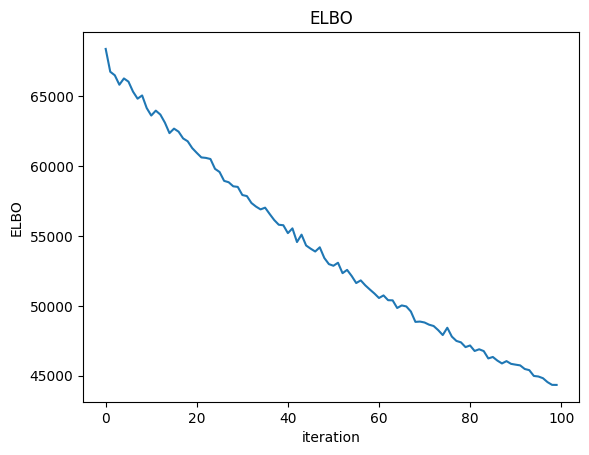

taking steps 101 to 200 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 44087.76:   0%|          | 0/100 [00:11<?, ?it/s]

Mean ELBO 44087.76:   1%|          | 1/100 [00:11<18:27, 11.18s/it]

Mean ELBO 44023.00:   1%|          | 1/100 [00:22<18:27, 11.18s/it]

...

Mean ELBO 37748.99:  98%|█████████▊| 98/100 [18:33<00:22, 11.29s/it]

Mean ELBO 37748.99:  99%|█████████▉| 99/100 [18:33<00:11, 11.26s/it]

Mean ELBO 37714.02:  99%|█████████▉| 99/100 [18:45<00:11, 11.26s/it]

Mean ELBO 37714.02: 100%|██████████| 100/100 [18:45<00:00, 11.24s/it]

Mean ELBO 37714.02: 100%|██████████| 100/100 [18:45<00:00, 11.25s/it]

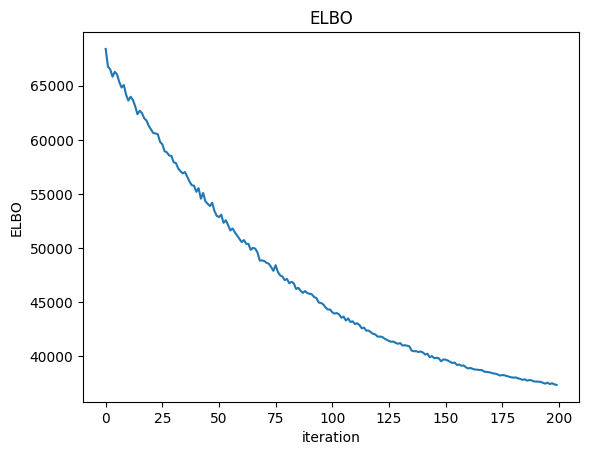

taking steps 201 to 300 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 37291.57:   0%|          | 0/100 [00:11<?, ?it/s]

Mean ELBO 37291.57:   1%|          | 1/100 [00:11<18:47, 11.39s/it]

Mean ELBO 37337.70:   1%|          | 1/100 [00:22<18:47, 11.39s/it]

...

Mean ELBO 35736.44:  98%|█████████▊| 98/100 [18:34<00:22, 11.26s/it]

Mean ELBO 35736.44:  99%|█████████▉| 99/100 [18:34<00:11, 11.25s/it]

Mean ELBO 35726.82:  99%|█████████▉| 99/100 [18:45<00:11, 11.25s/it]

Mean ELBO 35726.82: 100%|██████████| 100/100 [18:45<00:00, 11.31s/it]

Mean ELBO 35726.82: 100%|██████████| 100/100 [18:45<00:00, 11.26s/it]

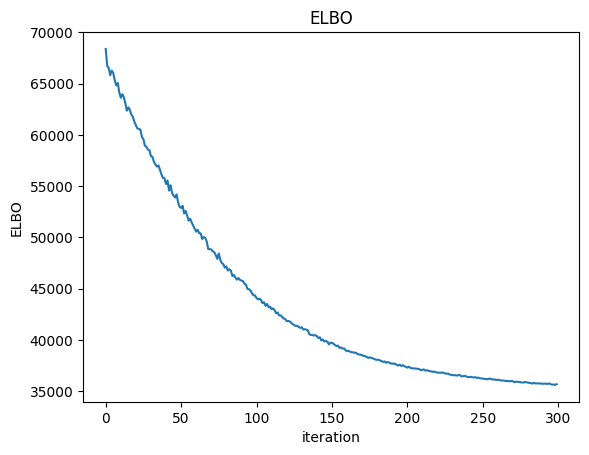

taking steps 301 to 400 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 35622.25:   0%|          | 0/100 [00:11<?, ?it/s]

Mean ELBO 35622.25:   1%|          | 1/100 [00:11<18:34, 11.26s/it]

Mean ELBO 35623.23:   1%|          | 1/100 [00:22<18:34, 11.26s/it]

...

Mean ELBO 35072.51:  98%|█████████▊| 98/100 [18:29<00:22, 11.31s/it]

Mean ELBO 35072.51:  99%|█████████▉| 99/100 [18:29<00:11, 11.27s/it]

Mean ELBO 35067.27:  99%|█████████▉| 99/100 [18:40<00:11, 11.27s/it]

Mean ELBO 35067.27: 100%|██████████| 100/100 [18:40<00:00, 11.25s/it]

Mean ELBO 35067.27: 100%|██████████| 100/100 [18:40<00:00, 11.21s/it]

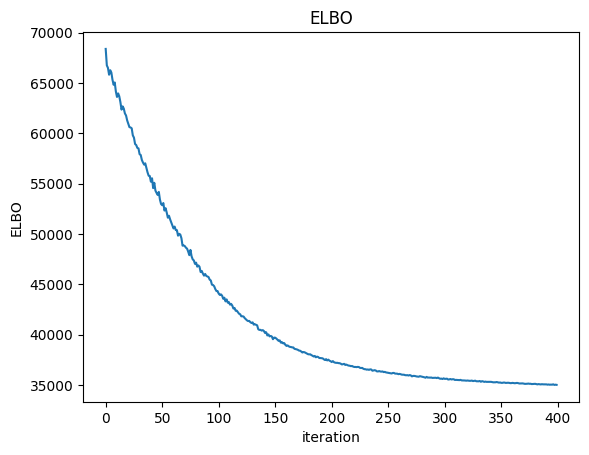

taking steps 401 to 500 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 35050.73:   0%|          | 0/100 [00:11<?, ?it/s]

Mean ELBO 35050.73:   1%|          | 1/100 [00:11<18:33, 11.25s/it]

Mean ELBO 35033.99:   1%|          | 1/100 [00:22<18:33, 11.25s/it]

...

Mean ELBO 34826.25:  98%|█████████▊| 98/100 [18:23<00:22, 11.18s/it]

Mean ELBO 34826.25:  99%|█████████▉| 99/100 [18:23<00:11, 11.14s/it]

Mean ELBO 34824.62:  99%|█████████▉| 99/100 [18:34<00:11, 11.14s/it]

Mean ELBO 34824.62: 100%|██████████| 100/100 [18:34<00:00, 11.19s/it]

Mean ELBO 34824.62: 100%|██████████| 100/100 [18:34<00:00, 11.14s/it]

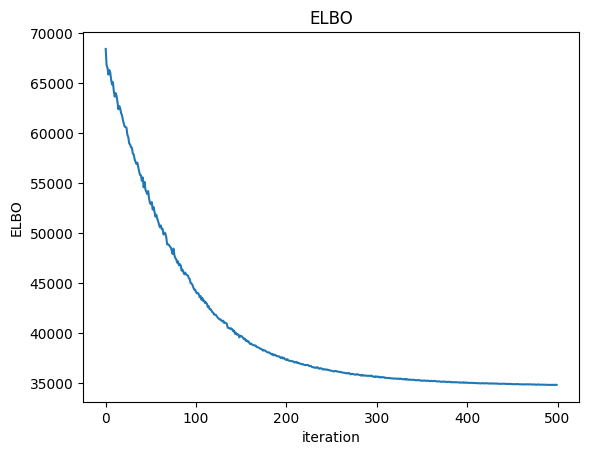

taking steps 501 to 600 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 34802.09:   0%|          | 0/100 [00:11<?, ?it/s]

Mean ELBO 34802.09:   1%|          | 1/100 [00:11<18:10, 11.01s/it]

Mean ELBO 34807.89:   1%|          | 1/100 [00:22<18:10, 11.01s/it]

...

Mean ELBO 34716.46:  98%|█████████▊| 98/100 [17:20<00:18,  9.28s/it]

Mean ELBO 34716.46:  99%|█████████▉| 99/100 [17:20<00:09,  9.30s/it]

Mean ELBO 34715.32:  99%|█████████▉| 99/100 [17:29<00:09,  9.30s/it]

Mean ELBO 34715.32: 100%|██████████| 100/100 [17:29<00:00,  9.28s/it]

Mean ELBO 34715.32: 100%|██████████| 100/100 [17:29<00:00, 10.50s/it]

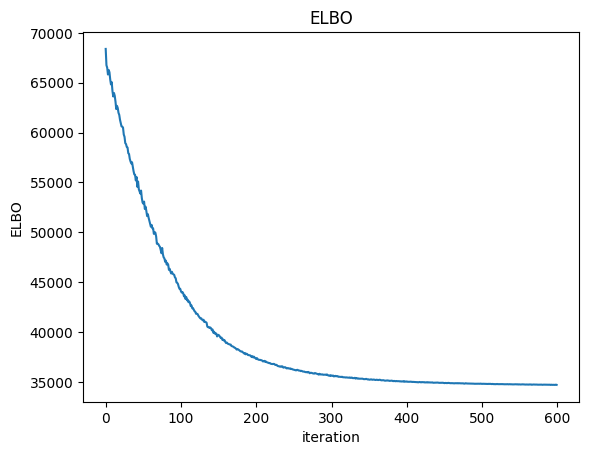

        policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0          0.461326     0.080456  5.282648           1.145811       1.226865   
1          0.031617     0.674636  0.743976           0.433657       0.601215   
2          0.848203     0.777331  2.040934           1.283475       1.927026   
3          0.469199     0.553914  3.375272           1.942958       2.305293   
4          0.434366     0.914882  1.110044           1.069966       1.327188   
...             ...          ...       ...                ...            ...   
102995     0.068195     0.377950  0.842204           1.124878       0.770149   
102996     0.460599     0.166490  1.516232           1.142399       0.515380   
102997     0.483691     0.270852  5.539423           1.667043       1.135760   
102998     0.377413     0.858897  1.785914           2.028279       0.690783   
102999     0.176157     0.628624  0.489766           0.849797       0.661227   

        cached rate  subject  
0       

        policy rate  reward rate  dec temp  habitual tendency  cached weight  \
0          0.220549     0.068486  4.332060           1.095525       0.688597   
1          0.203382     0.169705  0.576758           1.011168       0.645340   
2          0.441124     0.273074  0.186351           0.681167       0.876745   
3          0.383167     0.559523  3.986920           2.205318       1.493137   
4          0.558496     0.234261  1.619837           1.818839       0.900199   
...             ...          ...       ...                ...            ...   
102995     0.041559     0.444391  1.579512           1.166148       0.972332   
102996     0.503438     0.157747  1.788453           0.994380       0.741997   
102997     0.584990     0.226086  8.008641           1.832952       0.733839   
102998     0.259923     0.190671  1.291699           1.269928       0.886912   
102999     0.205913     0.914666  0.473296           0.685053       1.113242   

        cached rate  subject  
0       

In [13]:
if run_inference:

    # remove old inference?
    remove_old = True

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=remove_old, 
                                                    use_h=use_h)

    print('analyzing '+str(n_agents)+' data sets')

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    num_particles = 15


    print("this is inference using", type(inferrer))
    
    size_chunk = 100
    total_num_iter_so_far = 0

    for i in range(total_num_iter_so_far, num_steps, size_chunk):
        print('taking steps '+str(i+1)+' to '+str(i+size_chunk)+' out of total '+str(num_steps))

        fname_str = fname_base + str(total_num_iter_so_far+size_chunk)+'_'+str(n_agents)+'agents'

        iu.infer(inferrer, size_chunk, fname_str, num_particles, base_dir)
        total_num_iter_so_far += size_chunk

    inferrer.save_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.save_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 

    param_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

    # plt.figure()
    # vars_of_interest = ["inferred "+name for name in param_names]
    # f = sns.pairplot(data=mean_df, kind='reg', diag_kind="hist", corner=True,# hue="subject",
    #                     plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
    #                     grid_kws={"layout_pad": 1.5},
    #                     x_vars=vars_of_interest, y_vars=vars_of_interest)
    # f.map(tu.annot_corrfunc)
    # for p, p_range in enumerate(param_ranges):
    #     f.axes[n_pars-1,p].set_xlim(p_range)
    #     f.axes[p,0].set_ylim(p_range)
    # #f.axes[2,0].set_ylim(param_ranges[0])
    # #f.axes[1,0].set_ylim(param_ranges[1])
    # #f.axes[2,0].set_ylim(param_ranges[2])
    # plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
    # plt.show()

    # sample from posterior only at last time step and save results. Could be done at every step, if earlier posteriors are of interest, one can load the inferrer save and sample from that.
    mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 

<b>Or:</b> Set up agent and inference. Load past inference, decide whether to resample posterior or used stored samples

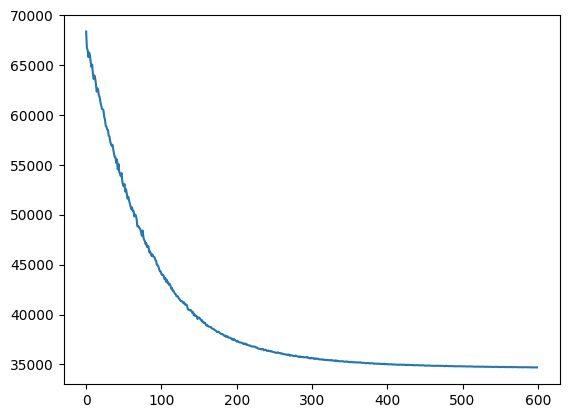

last ELBO: tensor(34705.8945)


In [14]:
if not run_inference:

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=False, 
                                                    use_h=use_h)
                                                    
    print('analyzing '+str(n_agents)+' data sets')

    resample = True

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 

plt.figure()
plt.plot(inferrer.loss)
plt.show()

print("last ELBO:", inferrer.loss[-1])

<Figure size 640x480 with 0 Axes>

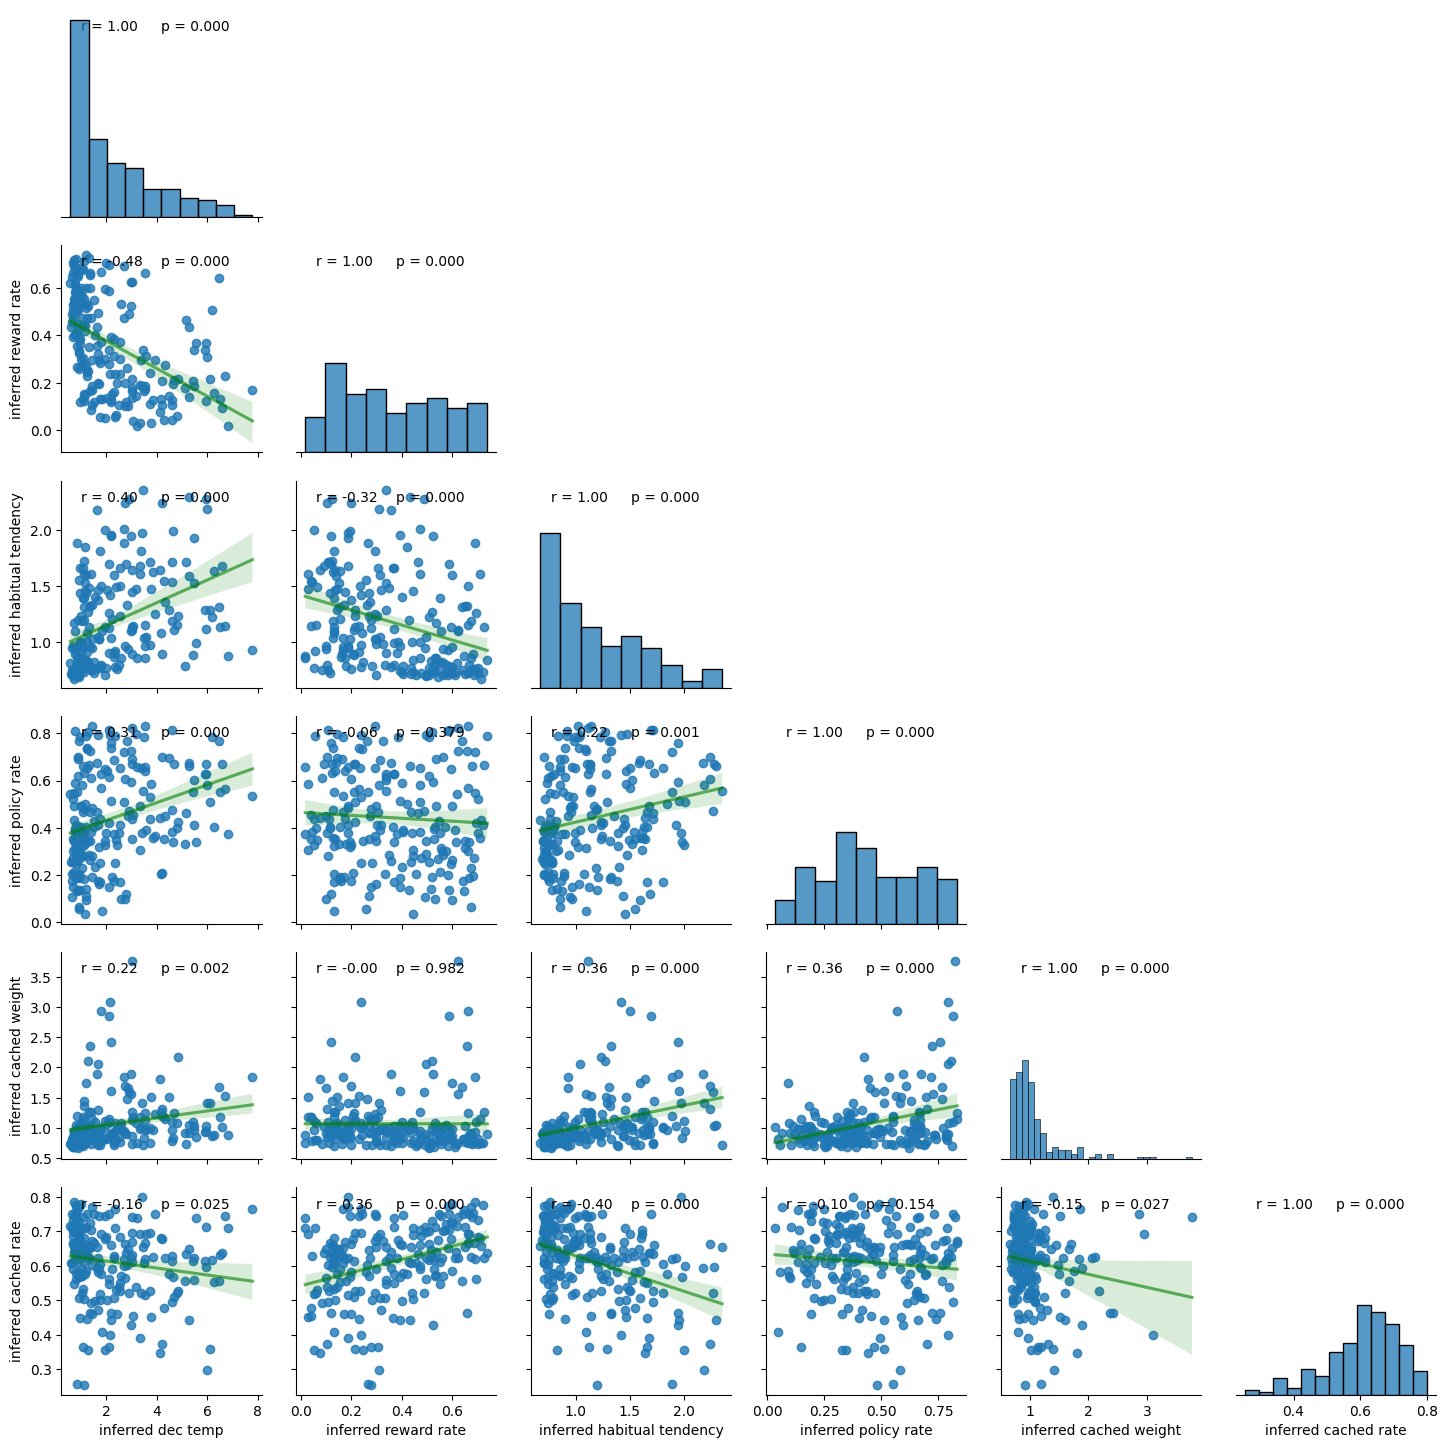

This is inference for the twostage task using the Bayesian prior-based contextual control model(BCC_6pars_planning_repetition_weight_cached) with 206 agents.


In [15]:
plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    grid_kws={"layout_pad": 1.5},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
# for p, p_range in enumerate(param_ranges):
#     f.axes[n_pars-1,p].set_xlim(p_range)
#     f.axes[p,0].set_ylim(p_range)
plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()
        
print("This is inference for the twostage task using the "+model_name+"("+agent_type+")"+" with "+str(n_agents)+" agents.")

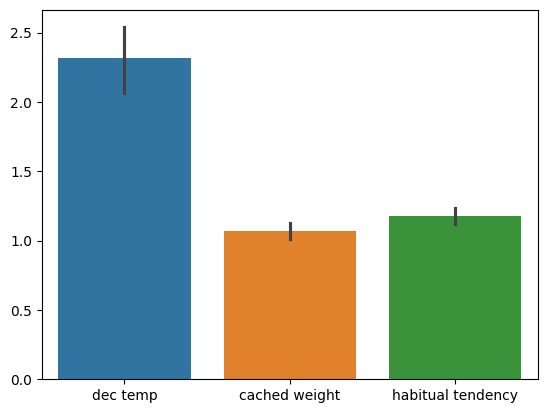

In [16]:
weight_df = pd.DataFrame({"dec temp": mean_df["inferred dec temp"], 
                            "cached weight": mean_df["inferred cached weight"], 
                            "habitual tendency": mean_df["inferred habitual tendency"]})

plt.figure()
sns.barplot(data=weight_df)
plt.show()

['inferred dec temp', 'inferred reward rate', 'inferred habitual tendency', 'inferred policy rate', 'inferred cached weight', 'inferred cached rate']


<Figure size 640x480 with 0 Axes>

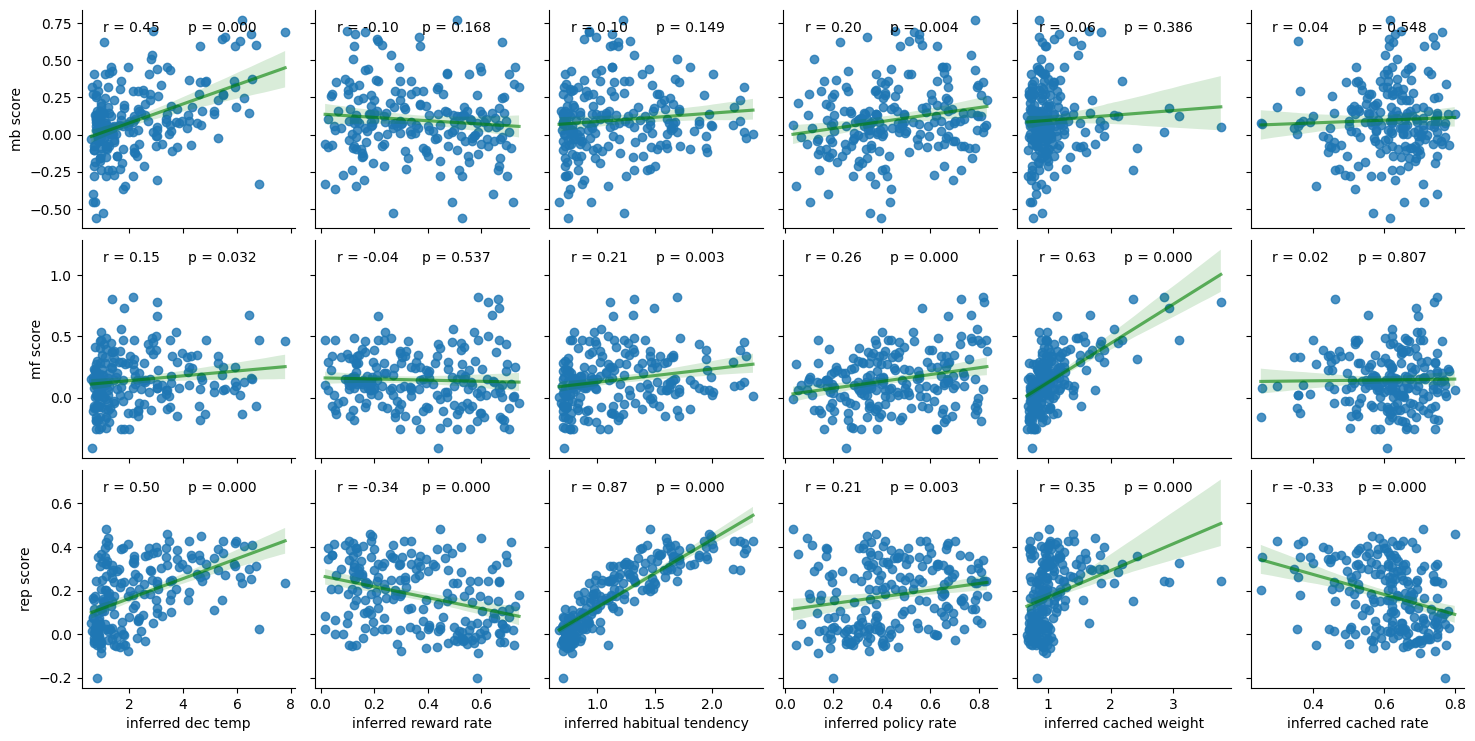

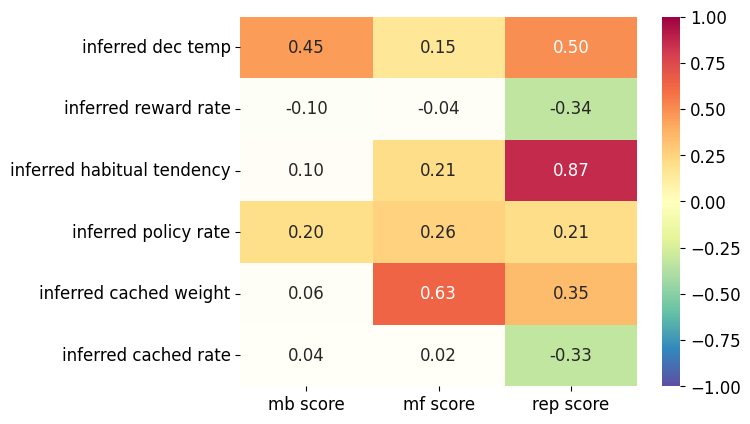

In [17]:
mean_scores_df = pd.concat([mean_df, scores_df], axis='columns')#, join="inner")

plt.figure()
x_vars_of_interest = ["inferred "+name for name in param_names]
print(x_vars_of_interest)
y_vars_of_interest = list(scores_df.keys())
f = sns.pairplot(data=mean_scores_df, kind='reg', #diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=x_vars_of_interest, y_vars=y_vars_of_interest)
f.map(tu.annot_corrfunc)
#for p, p_range in enumerate(param_plot_ranges):
#    f.axes[2,p].set_xlim(p_range)
#    f.axes[p,0].set_ylim(p_range)
#plt.title("BCC3 analysis 1 correlations with scores")
plt.show()

iu.plot_correlations(mean_scores_df, x_vars_of_interest, y_vars_of_interest)

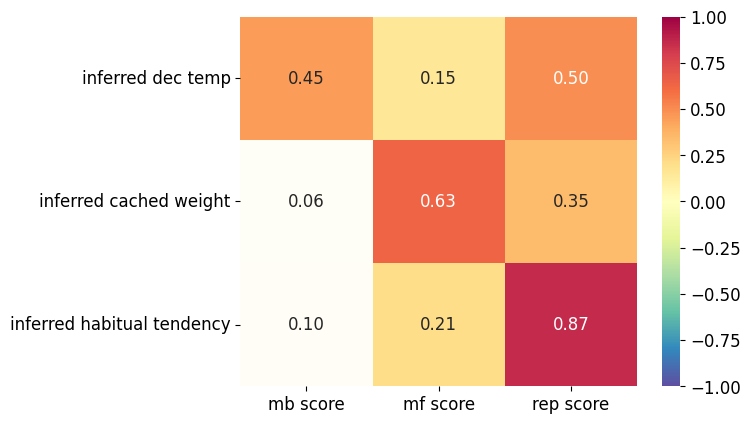

In [18]:
weight_names = ["inferred dec temp", "inferred cached weight", "inferred habitual tendency"]

iu.plot_correlations(mean_scores_df, weight_names, y_vars_of_interest)